# 9 · Validation and calibration

A fit always returns numbers. These are the checks that tell you whether to believe them:
recovery against a known truth, a posterior predictive check, and simulation-based calibration.

**Needs:** the base install.

> **Budgets here are illustrative, not publication-grade.** They are sized so the notebook runs in
> minutes. Before quoting any number, raise the budget until `result.info["converged"]` is `True`,
> and only compare fits that use the same `space=`.

In [1]:
from pathlib import Path

# Works whether the notebook is run from notebooks/ or from the repository root.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "tests" / "data").is_dir())
AT2017GFO = ROOT / "tests" / "data" / "at2017gfo.csv"

import warnings
warnings.filterwarnings("ignore")           # keep the tutorial output readable

import numpy as np
import matplotlib.pyplot as plt
import whisper_cbpf as wp

print("whisper_cbpf", wp.__version__)

whisper_cbpf 0.2.0


## Recovery against a known truth

Simulate from the model, fit the simulation, and ask whether the posterior finds the parameters you
put in. This is the first thing to run when you add a model.

Every fit here uses one prior, `PRIOR`, sized to the simulated transients; the SBC section below
draws its truths from the same prior, as SBC requires.

In [2]:
from whisper_cbpf.io import LightCurve

PRIOR = wp.Prior({
    "amplitude": wp.LogUniform(0.1, 10.0, name="amplitude"),
    "t0":        wp.Uniform(0.0, 15.0, name="t0"),
    "tau_rise":  wp.LogUniform(0.5, 10.0, name="tau_rise"),
    "tau_fall":  wp.LogUniform(2.0, 50.0, name="tau_fall"),
})
TRUTH = {"amplitude": 1.5, "t0": 6.0, "tau_rise": 2.5, "tau_fall": 14.0}
rng = np.random.default_rng(0)

times = np.linspace(0.5, 40.0, 60)
bands = np.array(["g"] * times.size)
clean = wp.get_model("bazin").predict(TRUTH, times, bands)
sigma = 0.05 * clean.max()

sim = LightCurve(time=times, band=bands,
                 flux=clean + sigma * rng.standard_normal(times.size),
                 flux_err=np.full(times.size, sigma), name="simulated")
print(sim.n_points, "points, data_mode =", sim.data_mode)

60 points, data_mode = flux_density


In [3]:
r = wp.fit(sim, "bazin", prior=PRIOR, sampler="mcmc", space="flux",
           nsteps=4000, burnin=1000, seed=0)
print("converged:", r.info["converged"])
print()
rec = wp.recovery_metrics(r, TRUTH)

# Keys starting with "_" are summaries, not parameters -- recovery_metrics and sbc_ranks both
# use that convention.
print(f"{'param':11s} {'truth':>9s} {'median':>10s} {'z':>7s}  in 68%  in 95%")
for name, m in rec.items():
    if name.startswith("_"):
        continue
    print(f"  {name:9s} {TRUTH[name]:9.3f} {m['median']:10.3f} {m['z_score']:7.2f} "
          f"{str(m['within_68']):>7s} {str(m['within_95']):>7s}")
print()
print("summary:", rec["_summary"])

converged: True

param           truth     median       z  in 68%  in 95%
  amplitude     1.500      1.463   -0.96    True    True
  t0            6.000      5.961   -0.12    True    True
  tau_rise      2.500      2.654    1.00   False    True
  tau_fall     14.000     14.672    1.07   False    True

summary: {'max_abs_z': 1.0726193788161265, 'rms_z': 0.878239378697886, 'coverage68': 0.5, 'coverage95': 1.0, 'n_params': 4}


`z` is `(median − truth) / std`. A well-behaved fit gives |z| of order 1 and the truth inside the
68% interval about two thirds of the time.

## Posterior predictive check

Does the fitted model actually reproduce the data? Draw from the posterior, forward-model each
draw, and compare the resulting band to the observations.

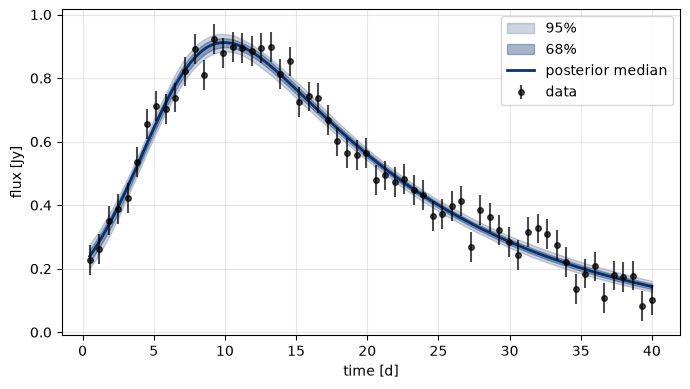

inside the 68% band : 0.733
inside the 95% band : 1.0
reduced chi2        : 0.759 (dof 56)
Bayesian p-value    : 0.89  -- far from 0 or 1 is healthy


In [4]:
ppc = wp.posterior_predictive_check(r, sim, n_draws=400, seed=0)

fig, ax = plt.subplots(figsize=(7, 4))
t = ppc["time_grid"]
ax.fill_between(t, ppc["lo95"], ppc["hi95"], alpha=0.20, color="#08306b", label="95%")
ax.fill_between(t, ppc["lo68"], ppc["hi68"], alpha=0.35, color="#08306b", label="68%")
ax.plot(t, ppc["median"], color="#08306b", lw=2, label="posterior median")
ax.errorbar(sim["time"], sim["flux"], yerr=sim["flux_err"], fmt="o", ms=4,
            color="k", alpha=0.7, label="data")
ax.set_xlabel("time [d]"); ax.set_ylabel("flux [Jy]"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("inside the 68% band :", round(ppc["ppc_coverage68"], 3))
print("inside the 95% band :", round(ppc["ppc_coverage95"], 3))
print("reduced chi2        :", round(ppc["reduced_chi2"], 3), f"(dof {ppc['dof']})")
print("Bayesian p-value    :", round(ppc["bayesian_p_value"], 3), " -- far from 0 or 1 is healthy")

## Simulation-based calibration

Recovery on one simulation tells you the fit was not broken. SBC tells you the *posterior width* is
right, which is a stronger claim and the one credible intervals depend on.

The idea: draw a truth from the prior, simulate, fit, and record the **rank** of the truth among the
posterior draws. If inference is calibrated, those ranks are uniform across many realisations. A
∪ shape means intervals are too narrow; a ∩ shape means too wide.

In [5]:
def one_realisation(seed):
    rng = np.random.default_rng(seed)
    truth = PRIOR.sample(rng)
    clean = wp.get_model("bazin").predict(truth, times, bands)
    s = max(0.05 * float(np.max(clean)), 1e-12)
    lc_i = LightCurve(time=times, band=bands,
                      flux=clean + s * rng.standard_normal(times.size),
                      flux_err=np.full(times.size, s))
    res = wp.fit(lc_i, "bazin", prior=PRIOR, sampler="mcmc", space="flux",
                 nsteps=1500, burnin=500, thin=10, seed=int(seed))
    return {p: wp.sbc_rank(res.samples[p].to_numpy(), truth[p]) for p in truth}


# 24 realisations keeps this notebook to a couple of minutes. A real SBC study needs hundreds.
ranks = {}
for i in range(24):
    for p, rk in one_realisation(100 + i).items():
        ranks.setdefault(p, []).append(rk)
ranks = {p: np.array(v) for p, v in ranks.items()}
print({p: v.shape for p, v in ranks.items()})

{'amplitude': (24,), 't0': (24,), 'tau_rise': (24,), 'tau_fall': (24,)}


In [6]:
diag = wp.sbc_ranks(ranks, n_bins=8)
print("summary:", diag["_summary"])
print()
for name, d in diag.items():
    if name.startswith("_"):
        continue
    verdict = "uniform" if d["uniformity_p"] > 0.05 else "NOT uniform"
    print(f"  {name:11s} uniformity p = {d['uniformity_p']:.3f}   chi2 = {d['chi2']:6.2f}"
          f"   L = {d['n_realizations']:3d}   {verdict}")

summary: {'min_uniformity_p': 0.06439143255906137, 'calibrated': True, 'n_params': 4}

  amplitude   uniformity p = 0.064   chi2 =  13.33   L =  24   uniform
  t0          uniformity p = 0.853   chi2 =   3.33   L =  24   uniform
  tau_rise    uniformity p = 0.540   chi2 =   6.00   L =  24   uniform
  tau_fall    uniformity p = 0.154   chi2 =  10.67   L =  24   uniform


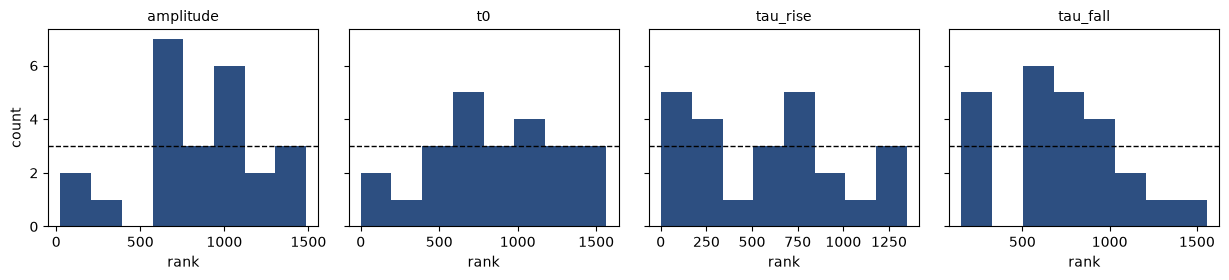

In [7]:
fig, axes = plt.subplots(1, len(ranks), figsize=(3.1 * len(ranks), 2.9), sharey=True)
for ax, (p, v) in zip(np.atleast_1d(axes), ranks.items()):
    ax.hist(v, bins=8, color="#08306b", alpha=0.85)
    ax.axhline(len(v) / 8, color="k", ls="--", lw=1)
    ax.set_title(p, fontsize=10); ax.set_xlabel("rank")
np.atleast_1d(axes)[0].set_ylabel("count")
plt.tight_layout(); plt.show()

With only 24 realisations the histograms are noisy and the dashed line is the uniform expectation.
Read the shape, not the individual bars — and run hundreds before publishing a calibration claim.

## Where next

* [08 · Metrics and model comparison](08_metrics_and_comparison.ipynb)
* [10 · Plotting](10_plotting.ipynb) — `plot_calibration` draws the coverage curve for you.